# Testing discipline_stats.py

Systematic tests for all functions in `src/discipline_stats.py`.
Run each cell and verify the output matches expected behaviour.

## Setup

In [1]:
import sys
sys.path.insert(0, '../src')

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from discipline_stats import (
    TestResults,
    filter_league_season,
    team_summary,
    venue_summary,
    plot_distribution,
    plot_home_away_distribution,
    plot_league_bar,
    plot_forest,
    check_normality,
    test_home_away,
    test_team_vs_rest,
    test_all_teams,
    compare_two_teams,
)

with open('../data/processed/team_matches.pkl', 'rb') as f:
    team_matches = pickle.load(f)

print('Import successful')
print(f'team_matches shape: {team_matches.shape}')

Import successful
team_matches shape: (53386, 20)


## 1. filter_league_season

**Test:** Filter Serie A 2526 and verify row count, team count, and column integrity.

In [2]:
ita = filter_league_season(team_matches, 'Serie_A', '2526')

assert len(ita) == 600, f'Expected 600 rows, got {len(ita)}'
assert ita['team'].nunique() == 20, f'Expected 20 teams, got {ita["team"].nunique()}'
assert 'fouls_committed' in ita.columns
assert 'yellow_cards' in ita.columns
print(f'PASS: {len(ita)} rows, {ita["team"].nunique()} teams')

# Test with different league
epl = filter_league_season(team_matches, 'Premier_League', '2526')
print(f'EPL: {len(epl)} rows, {epl["team"].nunique()} teams')

PASS: 600 rows, 20 teams
EPL: 618 rows, 20 teams


## 2. team_summary

**Test:** Verify columns, sorting, league mean attribute, and that diff_from_league sums roughly to zero.

In [3]:
ts = team_summary(ita, 'fouls_committed')

assert list(ts.columns) == ['total', 'mean', 'std', 'count', 'diff_from_league']
assert ts.index.name == 'team'
assert len(ts) == 20
assert ts['mean'].iloc[0] >= ts['mean'].iloc[-1], 'Should be sorted descending'
assert hasattr(ts, 'attrs') and 'league_mean' in ts.attrs
print(f'PASS: league_mean = {ts.attrs["league_mean"]:.2f}')
print(f'Top team: {ts.index[0]} ({ts["mean"].iloc[0]:.2f})')
print(f'Bottom team: {ts.index[-1]} ({ts["mean"].iloc[-1]:.2f})')
ts.head()

PASS: league_mean = 12.94
Top team: Verona (15.93)
Bottom team: Milan (10.00)


,total,mean,std,count,diff_from_league
team,,,,,
Verona,478.0,15.93,3.66,30,2.99
Cagliari,451.0,15.03,3.32,30,2.09
Roma,437.0,14.57,3.61,30,1.63
Torino,429.0,14.30,4.96,30,1.36
Udinese,424.0,14.13,3.90,30,1.19


## 3. venue_summary

**Test:** Verify index has home/away, columns match describe() output.

In [4]:
vs = venue_summary(ita, 'fouls_committed')

assert 'home' in vs.index and 'away' in vs.index
assert 'mean' in vs.columns and 'std' in vs.columns
print('PASS')
vs

PASS


,count,mean,std,min,25%,50%,75%,max
venue,,,,,,,,
away,300.0,13.166667,4.452524,3.0,10.0,13.0,16.0,29.0
home,300.0,12.720000,3.838060,3.0,10.0,13.0,15.0,26.0


## 4. Plot functions

**Test:** Each should return (fig, ax), produce a visible plot, and accept custom parameters.

PASS: plot_distribution (default)


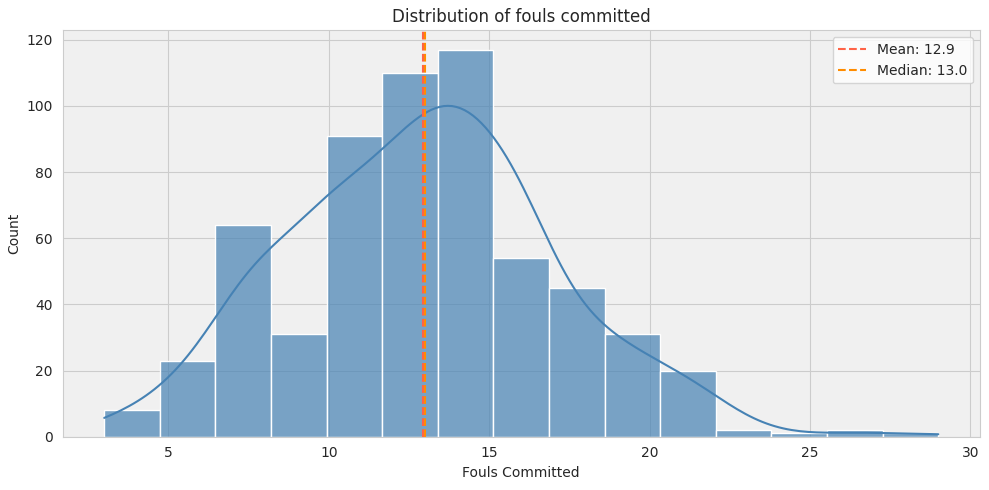

In [5]:
# 4a. plot_distribution — default
fig, ax = plot_distribution(ita, 'fouls_committed')
assert fig is not None and ax is not None
print('PASS: plot_distribution (default)')

PASS: plot_distribution (custom)


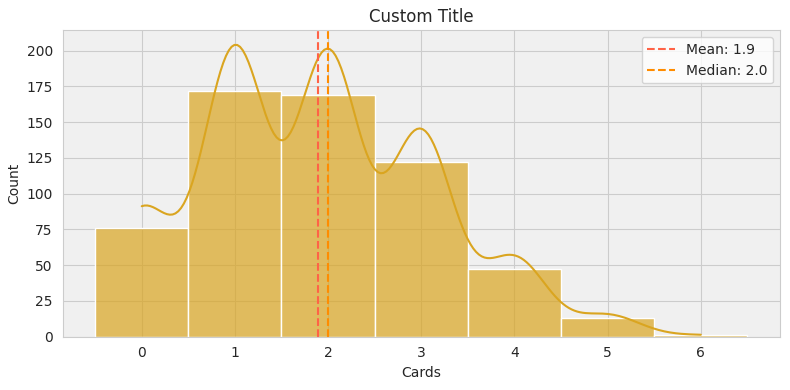

In [6]:
# 4b. plot_distribution — custom params
fig, ax = plot_distribution(ita, 'yellow_cards', title='Custom Title',
                            color='goldenrod', bins=range(0, 10),
                            figsize=(8, 4), xlabel='Cards', discrete=True)
print('PASS: plot_distribution (custom)')

PASS: plot_home_away_distribution


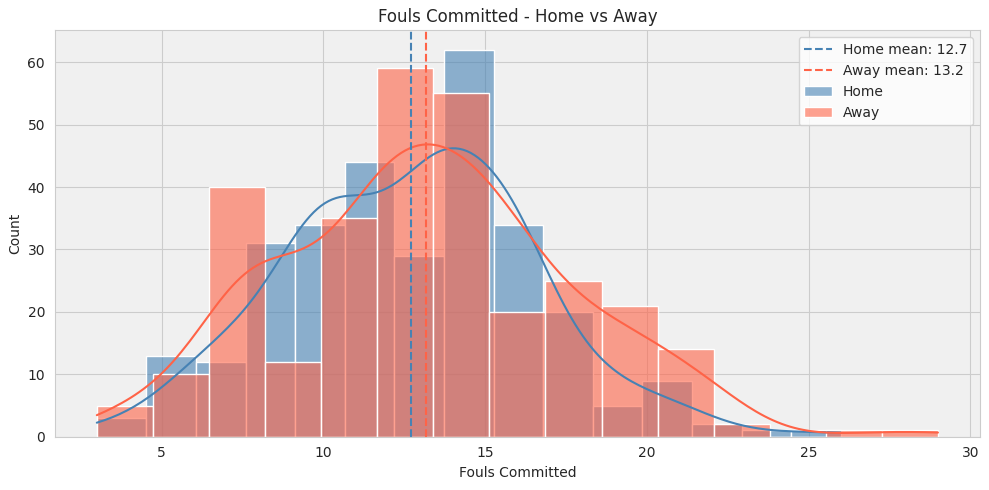

In [7]:
# 4c. plot_home_away_distribution
fig, ax = plot_home_away_distribution(ita, 'fouls_committed')
assert fig is not None and ax is not None
print('PASS: plot_home_away_distribution')

PASS: plot_league_bar


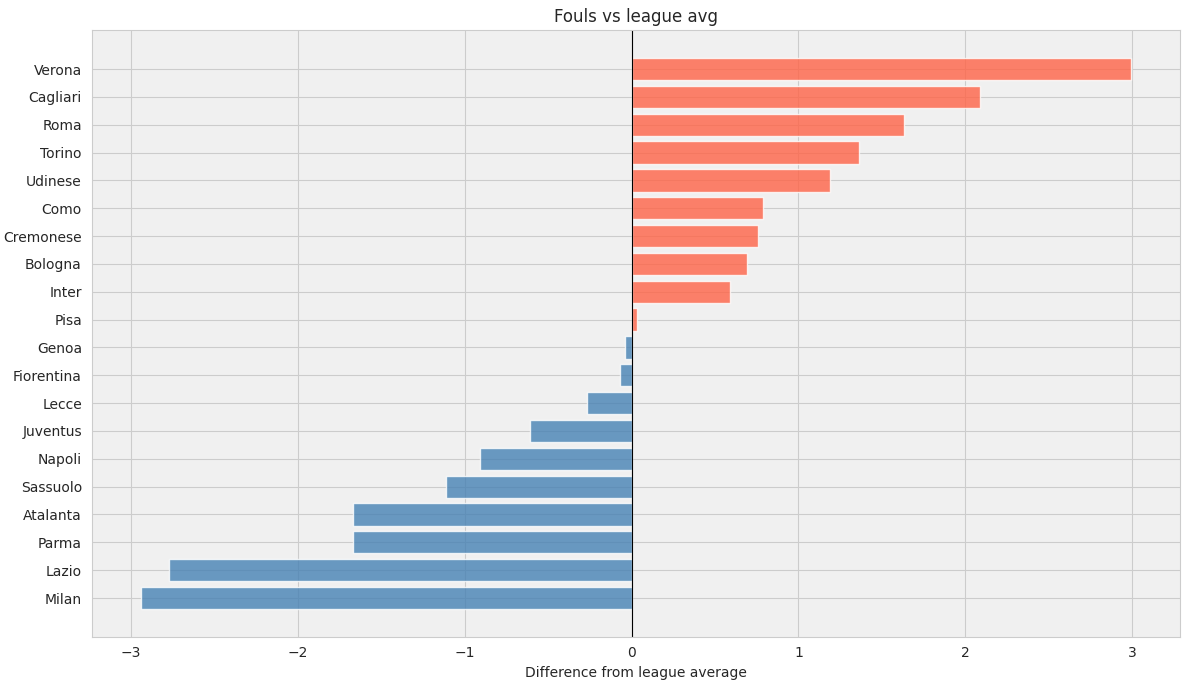

In [8]:
# 4d. plot_league_bar
ts_fouls = team_summary(ita, 'fouls_committed')
fig, ax = plot_league_bar(ts_fouls, title='Fouls vs league avg')
assert fig is not None and ax is not None
print('PASS: plot_league_bar')

## 5. check_normality

**Test:** Returns fig + results dict with All/Home/Away keys, each having W and p_value.

All    -- W=0.9894, p=0.000245 Not normal (p<0.05)
Home   -- W=0.9887, p=0.019606 Not normal (p<0.05)
Away   -- W=0.9873, p=0.009606 Not normal (p<0.05)
PASS: check_normality


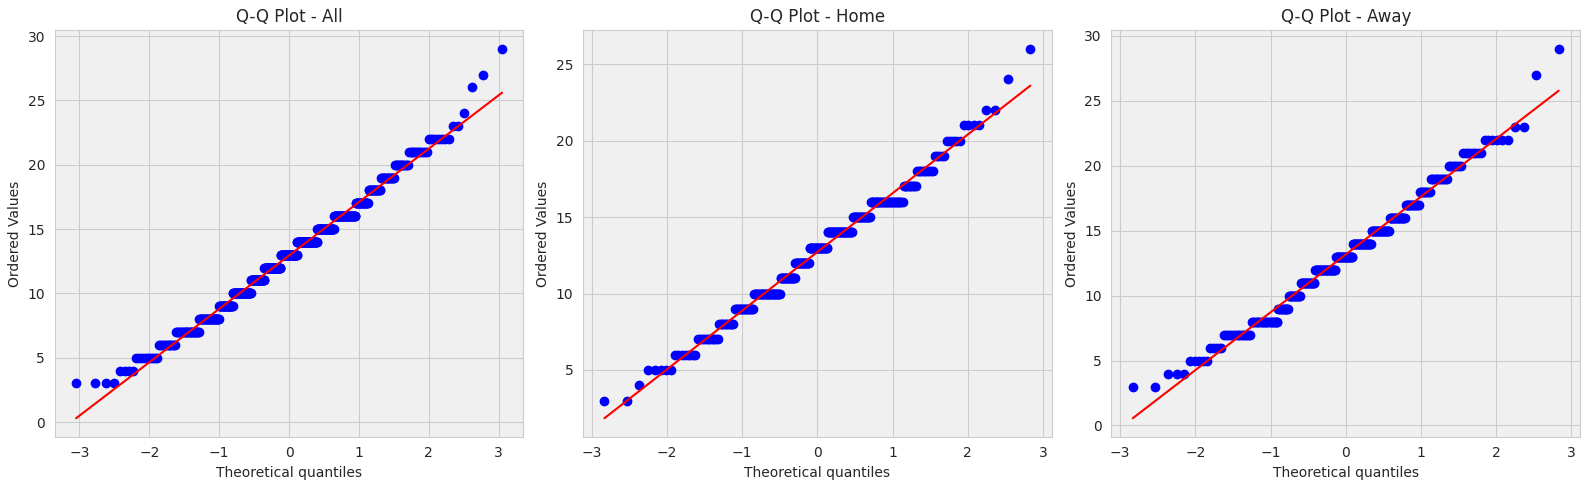

In [9]:
fig, norm_results = check_normality(ita, 'fouls_committed')

assert fig is not None
assert set(norm_results.keys()) == {'All', 'Home', 'Away'}
for k, v in norm_results.items():
    assert 'W' in v and 'p_value' in v
print('PASS: check_normality')

## 6. TestResults class

**Test:** Constructor, __repr__, show(), to_dict(), to_frame().

In [10]:
# Create a dummy TestResults
tr = TestResults(
    title='Test comparison',
    stats_dict={'mean_a': 10.0, 'mean_b': 12.0, 'difference': -2.0},
    tests_dict={
        'welch_t': {'statistic': -2.5, 'p_value': 0.013},
        'mannwhitney': {'statistic': 350.0, 'p_value': 0.045},
        'permutation': {'statistic': None, 'p_value': 0.018},
    },
    effect_sizes={'cohens_d': -0.55, 'rank_biserial': 0.22}
)

# Test __repr__
print('--- Full output ---')
print(tr)
print()

# Test show() with filter
print('--- Welch only ---')
tr.show('welch_t')
print()

# Test to_dict
d = tr.to_dict()
assert 'welch_t_p' in d
assert 'mannwhitney_stat' in d
assert 'cohens_d' in d
print(f'to_dict keys: {list(d.keys())}')

# Test to_frame
frame = tr.to_frame()
assert isinstance(frame, pd.DataFrame)
assert len(frame) == 1
print(f'to_frame shape: {frame.shape}')
print('PASS: TestResults')

--- Full output ---
Test comparison
--------------------------------------------------
  mean_a                    10.0000
  mean_b                    12.0000
  difference                -2.0000
--------------------------------------------------
  welch_t                   stat=-2.5000, p=0.0130  (Sig.)
  mannwhitney               stat=350.0000, p=0.0450  (Sig.)
  permutation               p=0.0180  (Sig.)
--------------------------------------------------
  cohens_d                  -0.5500
  rank_biserial             0.2200

--- Welch only ---
Test comparison
--------------------------------------------------
  mean_a                    10.0000
  mean_b                    12.0000
  difference                -2.0000
--------------------------------------------------
  welch_t                   stat=-2.5000, p=0.0130  (Sig.)
--------------------------------------------------
  cohens_d                  -0.5500
  rank_biserial             0.2200

to_dict keys: ['mean_a', 'mean_b', 'diff

## 7. test_home_away

**Test:** Returns TestResults with correct tests. Compare p-values with known values from 02b notebook.

In [11]:
# Fouls — known result: not significant
r_fouls = test_home_away(ita, 'fouls_committed')
print(r_fouls)
assert isinstance(r_fouls, TestResults)
assert r_fouls.tests['welch_t']['p_value'] > 0.05, 'Fouls home/away should NOT be significant'
print('PASS: fouls home/away not significant')

Home vs Away -- fouls_committed
--------------------------------------------------
  home_mean                 12.7200
  away_mean                 13.1667
  difference (away-home)    +0.4467
  home_std                  3.8381
  away_std                  4.4525
  home_n                    300
  away_n                    300
--------------------------------------------------
  levene                    stat=4.9457, p=0.0265  (Sig.)
  student_t                 stat=-1.3161, p=0.1886  (Not sig.)
  welch_t                   stat=-1.3161, p=0.1887  (Not sig.)
  mannwhitney               stat=42798.0000, p=0.2984  (Not sig.)
  permutation               p=0.1935  (Not sig.)
--------------------------------------------------
  cohens_d                  0.1075
  rank_biserial             0.0489
PASS: fouls home/away not significant


In [12]:
# Yellow cards — known result: significant
r_yc = test_home_away(ita, 'yellow_cards')
print(r_yc)
assert r_yc.tests['welch_t']['p_value'] < 0.05, 'Yellow cards home/away SHOULD be significant'
print('PASS: yellow cards home/away significant')

Home vs Away -- yellow_cards
--------------------------------------------------
  home_mean                 1.7733
  away_mean                 2.0100
  difference (away-home)    +0.2367
  home_std                  1.2084
  away_std                  1.2497
  home_n                    300
  away_n                    300
--------------------------------------------------
  levene                    stat=0.3423, p=0.5587  (Not sig.)
  student_t                 stat=-2.3581, p=0.0187  (Sig.)
  welch_t                   stat=-2.3581, p=0.0187  (Sig.)
  mannwhitney               stat=40168.5000, p=0.0191  (Sig.)
  permutation               p=0.0215  (Sig.)
--------------------------------------------------
  cohens_d                  0.1925
  rank_biserial             0.1074
PASS: yellow cards home/away significant


In [13]:
# Test .show() with selective tests
print('--- Welch + permutation only ---')
r_fouls.show('welch_t', 'permutation')

--- Welch + permutation only ---
Home vs Away -- fouls_committed
--------------------------------------------------
  home_mean                 12.7200
  away_mean                 13.1667
  difference (away-home)    +0.4467
  home_std                  3.8381
  away_std                  4.4525
  home_n                    300
  away_n                    300
--------------------------------------------------
  welch_t                   stat=-1.3161, p=0.1887  (Not sig.)
  permutation               p=0.1935  (Not sig.)
--------------------------------------------------
  cohens_d                  0.1075
  rank_biserial             0.0489


## 8. test_team_vs_rest

**Test:** Verona should be significantly above average for fouls. Milan significantly below.

In [14]:
r_verona = test_team_vs_rest(ita, 'fouls_committed', 'Verona')
print(r_verona)
assert r_verona.tests['welch_t']['p_value'] < 0.01
assert r_verona.effect_sizes['cohens_d'] > 0.5
print('PASS: Verona significantly above average')

Verona vs Rest -- fouls_committed
--------------------------------------------------
  team                      Verona
  team_mean                 15.9333
  rest_mean                 12.7860
  difference (team-rest)    +3.1474
  team_std                  3.6571
  rest_std                  4.1271
  team_n                    30
  rest_n                    570
--------------------------------------------------
  student_t                 stat=4.0926, p=0.0000  (Sig.)
  welch_t                   stat=4.5633, p=0.0001  (Sig.)
  mannwhitney               stat=12164.5000, p=0.0001  (Sig.)
  permutation               p=0.0000  (Sig.)
--------------------------------------------------
  cohens_d                  0.8072
  rank_biserial             -0.4227
PASS: Verona significantly above average


In [15]:
r_milan = test_team_vs_rest(ita, 'fouls_committed', 'Milan')
print(r_milan)
assert r_milan.tests['welch_t']['p_value'] < 0.01
assert r_milan.effect_sizes['cohens_d'] < -0.5
print('PASS: Milan significantly below average')

Milan vs Rest -- fouls_committed
--------------------------------------------------
  team                      Milan
  team_mean                 10.0000
  rest_mean                 13.0982
  difference (team-rest)    -3.0982
  team_std                  3.1623
  rest_std                  4.1498
  team_n                    30
  rest_n                    570
--------------------------------------------------
  student_t                 stat=-4.0269, p=0.0001  (Sig.)
  welch_t                   stat=-5.1385, p=0.0000  (Sig.)
  mannwhitney               stat=4574.0000, p=0.0000  (Sig.)
  permutation               p=0.0002  (Sig.)
--------------------------------------------------
  cohens_d                  -0.8398
  rank_biserial             0.4650
PASS: Milan significantly below average


## 9. test_all_teams

**Test:** Returns DataFrame with 20 rows, correct columns, sorted by mean descending.

In [16]:
all_results = test_all_teams(ita, 'fouls_committed', n_permutations=1_000)  # fewer perms for speed

assert isinstance(all_results, pd.DataFrame)
assert len(all_results) == 20
assert 'team' in all_results.columns
assert 'welch_t_p' in all_results.columns
assert 'mannwhitney_p' in all_results.columns
assert 'cohens_d' in all_results.columns
assert all_results['team_mean'].iloc[0] >= all_results['team_mean'].iloc[-1]
print('PASS: test_all_teams')
all_results.head()

PASS: test_all_teams


,team,team_mean,rest_mean,difference (team-rest),team_std,rest_std,team_n,rest_n,student_t_stat,student_t_p,welch_t_stat,welch_t_p,mannwhitney_stat,mannwhitney_p,permutation_p,cohens_d,rank_biserial
19,Verona,15.9333,12.7860,3.1474,3.6571,4.1271,30,570,4.0926,0.0000,4.5633,0.0001,12164.5,0.0001,0.000,0.8072,-0.4227
4,Cagliari,15.0333,12.8333,2.2000,3.3165,4.1723,30,570,2.8404,0.0047,3.4909,0.0014,11413.5,0.0019,0.006,0.5837,-0.3349
3,Roma,14.5667,12.8579,1.7088,3.6073,4.1715,30,570,2.2003,0.0282,2.5078,0.0172,10764.0,0.0165,0.019,0.4382,-0.2589
16,Torino,14.3000,12.8719,1.4281,4.9630,4.1053,30,570,1.8366,0.0668,1.5484,0.1316,10201.0,0.0737,0.060,0.3136,-0.1931
8,Udinese,14.1333,12.8807,1.2526,3.9017,4.1661,30,570,1.6099,0.1079,1.7080,0.0972,10141.5,0.0847,0.119,0.3104,-0.1861


## 10. plot_forest

**Test:** Uses output of test_all_teams. Should produce a forest plot with coloured dots.

PASS: plot_forest


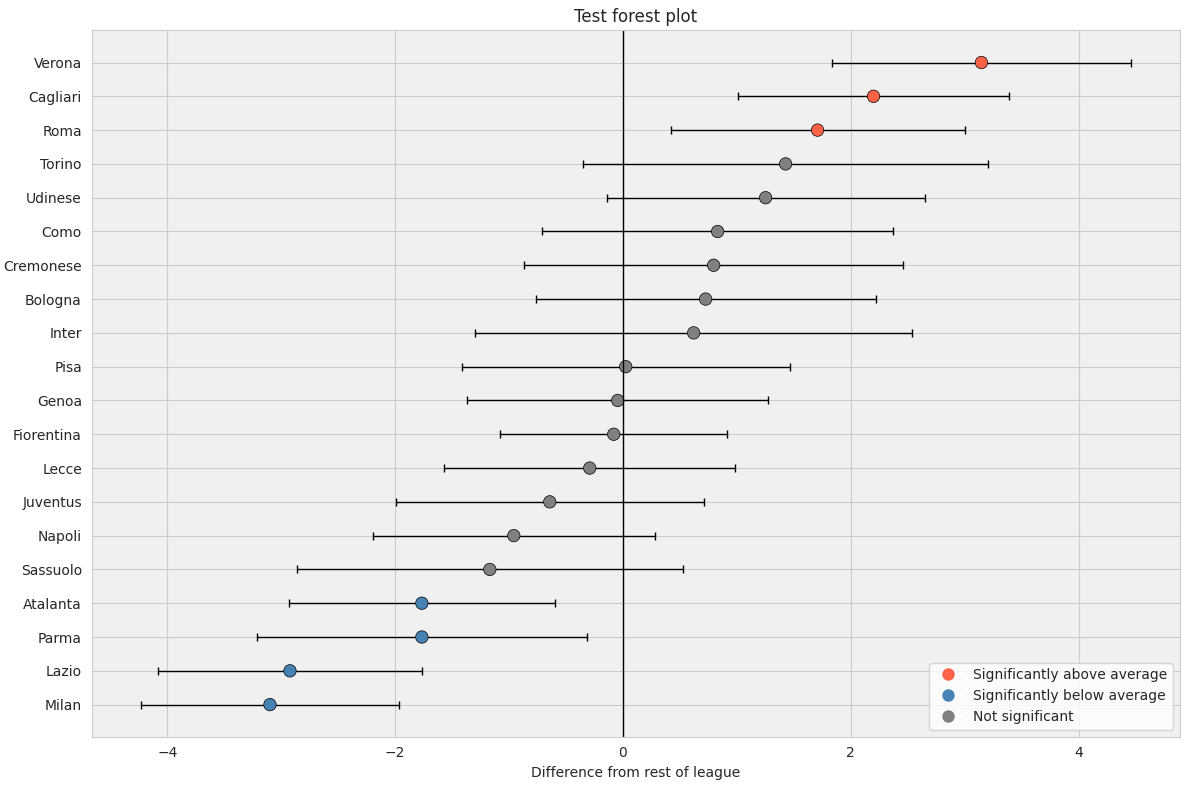

In [17]:
# Rename columns to match what plot_forest expects
plot_results = all_results.rename(columns={
    'difference (team-rest)': 'diff',
    'welch_t_p': 'welch_p'
})

fig, ax = plot_forest(plot_results, ita, 'fouls_committed',
                      title='Test forest plot')
assert fig is not None
print('PASS: plot_forest')

## 11. compare_two_teams

**Test:** Verona vs Milan should be highly significant. Roma vs Torino should not.

In [18]:
r_vm = compare_two_teams(ita, 'fouls_committed', 'Verona', 'Milan')
print(r_vm)
assert r_vm.tests['welch_t']['p_value'] < 0.001
assert r_vm.effect_sizes['cohens_d'] > 1.0
print('PASS: Verona vs Milan significant')

Verona vs Milan -- fouls_committed
--------------------------------------------------
  team_a                    Verona
  team_b                    Milan
  mean_a                    15.9333
  mean_b                    10.0000
  difference (Verona-Milan) +5.9333
  std_a                     3.6571
  std_b                     3.1623
  n_a                       30
  n_b                       30
--------------------------------------------------
  welch_t                   stat=6.7218, p=0.0000  (Sig.)
  mannwhitney               stat=809.0000, p=0.0000  (Sig.)
  permutation               p=0.0000  (Sig.)
--------------------------------------------------
  cohens_d                  1.7356
  rank_biserial             -0.7978
PASS: Verona vs Milan significant


In [19]:
r_rt = compare_two_teams(ita, 'fouls_committed', 'Roma', 'Torino')
print(r_rt)
assert r_rt.tests['welch_t']['p_value'] > 0.1
print('PASS: Roma vs Torino not significant')

Roma vs Torino -- fouls_committed
--------------------------------------------------
  team_a                    Roma
  team_b                    Torino
  mean_a                    14.5667
  mean_b                    14.3000
  difference (Roma-Torino)  +0.2667
  std_a                     3.6073
  std_b                     4.9630
  n_a                       30
  n_b                       30
--------------------------------------------------
  welch_t                   stat=0.2381, p=0.8128  (Not sig.)
  mannwhitney               stat=463.5000, p=0.8470  (Not sig.)
  permutation               p=0.8366  (Not sig.)
--------------------------------------------------
  cohens_d                  0.0615
  rank_biserial             -0.0300
PASS: Roma vs Torino not significant


## 12. Cross-column test

**Test:** Same functions work for yellow_cards without modification.

In [20]:
ts_yc = team_summary(ita, 'yellow_cards')
r_juve_yc = test_team_vs_rest(ita, 'yellow_cards', 'Juventus')
r_h2h_yc = compare_two_teams(ita, 'yellow_cards', 'Cagliari', 'Juventus')

print(ts_yc.head(3))
print()
print(r_juve_yc)
print()
print(r_h2h_yc)

assert r_juve_yc.tests['welch_t']['p_value'] < 0.01, 'Juve yellow cards should be significant'
print('PASS: cross-column test')

            total  mean   std  count  diff_from_league
team                                                  
Cagliari     73.0  2.43  1.55     30              0.54
Verona       68.0  2.27  1.26     30              0.38
Fiorentina   67.0  2.23  1.22     30              0.34

Juventus vs Rest -- yellow_cards
--------------------------------------------------
  team                      Juventus
  team_mean                 1.2000
  rest_mean                 1.9281
  difference (team-rest)    -0.7281
  team_std                  1.0635
  rest_std                  1.2323
  team_n                    30
  rest_n                    570
--------------------------------------------------
  student_t                 stat=-3.1738, p=0.0016  (Sig.)
  welch_t                   stat=-3.6238, p=0.0010  (Sig.)
  mannwhitney               stat=5619.0000, p=0.0011  (Sig.)
  permutation               p=0.0013  (Sig.)
--------------------------------------------------
  cohens_d                  -0.6326
  

## 13. Cross-league test

**Test:** Functions work on a different league.

In [21]:
epl = filter_league_season(team_matches, 'Premier_League', '2526')
print(f'EPL rows: {len(epl)}, teams: {epl["team"].nunique()}')

ts_epl = team_summary(epl, 'fouls_committed')
r_epl = test_home_away(epl, 'fouls_committed')
print()
print(r_epl)
print('PASS: cross-league test')

EPL rows: 618, teams: 20

Home vs Away -- fouls_committed
--------------------------------------------------
  home_mean                 10.5566
  away_mean                 10.9709
  difference (away-home)    +0.4142
  home_std                  3.2154
  away_std                  3.3675
  home_n                    309
  away_n                    309
--------------------------------------------------
  levene                    stat=1.4997, p=0.2212  (Not sig.)
  student_t                 stat=-1.5639, p=0.1183  (Not sig.)
  welch_t                   stat=-1.5639, p=0.1184  (Not sig.)
  mannwhitney               stat=44405.0000, p=0.1312  (Not sig.)
  permutation               p=0.1151  (Not sig.)
--------------------------------------------------
  cohens_d                  0.1258
  rank_biserial             0.0699
PASS: cross-league test


## Summary

If all cells above show PASS, the library is working correctly.

## Additional tests

### Seasons

In [23]:
ita_2122 = filter_league_season(team_matches, 'Serie_A', '2122')
print(ita_2122.shape)
ita_2122.head()

(760, 20)


,season,date,team,opponent,yellow_cards,red_cards,fouls_committed,fouls_received,shots,shots_opponent,shots_on_target,shots_on_target_opponent,corners,corners_opponent,goals_scored,goals_conceded,match_result,venue,team_result,league
1440,2122,21/08/2021,Inter,Genoa,1.0,0.0,18.0,7.0,17.0,11.0,8.0,5.0,8.0,2.0,4.0,0.0,H,home,W,Serie_A
1441,2122,21/08/2021,Verona,Sassuolo,3.0,1.0,11.0,12.0,12.0,15.0,4.0,8.0,7.0,4.0,2.0,3.0,A,home,L,Serie_A
1442,2122,21/08/2021,Empoli,Lazio,2.0,0.0,13.0,10.0,16.0,8.0,5.0,5.0,5.0,3.0,1.0,3.0,A,home,L,Serie_A
1443,2122,21/08/2021,Torino,Atalanta,2.0,0.0,17.0,13.0,19.0,6.0,8.0,2.0,5.0,1.0,1.0,2.0,A,home,L,Serie_A
1444,2122,22/08/2021,Bologna,Salernitana,6.0,2.0,13.0,15.0,18.0,8.0,7.0,4.0,9.0,4.0,3.0,2.0,H,home,W,Serie_A


In [26]:
team_summary(ita_2122, 'fouls_committed')

,total,mean,std,count,diff_from_league
team,,,,,
Torino,637.0,16.76,4.28,38,3.48
Udinese,561.0,14.76,4.04,38,1.48
Verona,560.0,14.74,3.74,38,1.46
Genoa,560.0,14.74,4.54,38,1.46
Cagliari,545.0,14.34,3.04,38,1.06
Venezia,522.0,13.74,4.46,38,0.46
Atalanta,512.0,13.47,2.92,38,0.19
Spezia,511.0,13.45,3.75,38,0.17
Juventus,508.0,13.37,3.74,38,0.09


In [27]:
venue_summary(ita_2122, 'fouls_committed')

,count,mean,std,min,25%,50%,75%,max
venue,,,,,,,,
away,380.0,13.497368,3.925089,4.0,11.0,13.0,16.0,28.0
home,380.0,13.063158,3.837217,3.0,10.0,13.0,15.0,28.0


In [28]:
test_home_away(ita_2122, 'fouls_committed')

Home vs Away -- fouls_committed
--------------------------------------------------
  home_mean                 13.0632
  away_mean                 13.4974
  difference (away-home)    +0.4342
  home_std                  3.8372
  away_std                  3.9251
  home_n                    380
  away_n                    380
--------------------------------------------------
  levene                    stat=1.2025, p=0.2732  (Not sig.)
  student_t                 stat=-1.5420, p=0.1235  (Not sig.)
  welch_t                   stat=-1.5420, p=0.1235  (Not sig.)
  mannwhitney               stat=67966.0000, p=0.1604  (Not sig.)
  permutation               p=0.1256  (Not sig.)
--------------------------------------------------
  cohens_d                  0.1119
  rank_biserial             0.0586

In [30]:
result_ita_2122_all_teams = test_all_teams(ita_2122, 'fouls_committed')
result_ita_2122_all_teams

,team,team_mean,rest_mean,difference (team-rest),team_std,rest_std,team_n,rest_n,student_t_stat,student_t_p,welch_t_stat,welch_t_p,mannwhitney_stat,mannwhitney_p,permutation_p,cohens_d,rank_biserial
3,Torino,16.7632,13.0970,3.6662,4.2771,3.7784,38,722,5.7903,0.0000,5.1787,0.0000,20369.5,0.0000,0.0000,0.9085,-0.4849
5,Udinese,14.7632,13.2022,1.5609,4.0366,3.8639,38,722,2.4218,0.0157,2.3283,0.0250,16759.0,0.0207,0.0167,0.3951,-0.2217
14,Genoa,14.7368,13.2036,1.5332,4.5362,3.8359,38,722,2.3785,0.0176,2.0454,0.0475,16542.5,0.0317,0.0185,0.3650,-0.2059
1,Verona,14.7368,13.2036,1.5332,3.7394,3.8798,38,722,2.3785,0.0176,2.4589,0.0182,17228.5,0.0076,0.0182,0.4024,-0.2559
8,Cagliari,14.3421,13.2244,1.1177,3.0427,3.9180,38,722,1.7309,0.0839,2.1717,0.0353,16418.5,0.0400,0.0892,0.3186,-0.1969
19,Venezia,13.7368,13.2562,0.4806,4.4581,3.8544,38,722,0.7431,0.4577,0.6519,0.5182,14164.5,0.7344,0.4641,0.1153,-0.0325
10,Atalanta,13.4737,13.2701,0.2036,2.9200,3.9305,38,722,0.3147,0.7531,0.4107,0.6833,14570.0,0.5171,0.7670,0.0588,-0.0621
18,Spezia,13.4474,13.2715,0.1759,3.7467,3.8944,38,722,0.2719,0.7858,0.2815,0.7797,13877.5,0.9037,0.7919,0.0460,-0.0116
13,Juventus,13.3684,13.2756,0.0928,3.7447,3.8946,38,722,0.1434,0.8860,0.1486,0.8826,13927.0,0.8740,0.8997,0.0243,-0.0152
2,Empoli,13.3421,13.2770,0.0651,3.4818,3.9071,38,722,0.1006,0.9199,0.1116,0.9117,14183.0,0.7238,0.9293,0.0176,-0.0339


KeyError: 'diff'

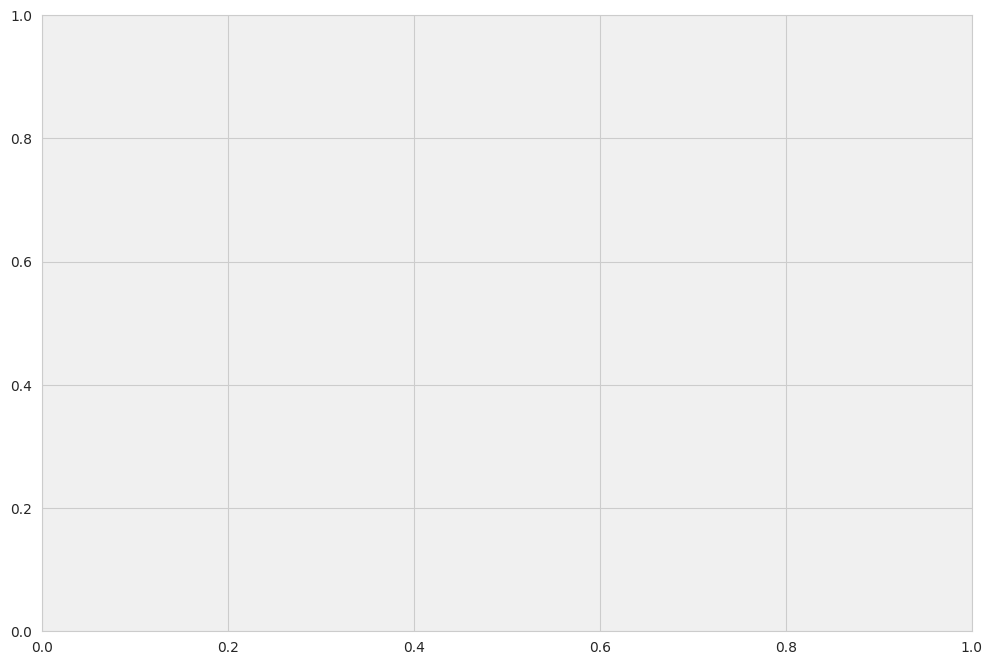

In [33]:
plot_forest(results_df=result_ita_2122_all_teams,
            df=ita_2122,
            column='fouls_committed')